# IDS Feature Selection & Hyperparameter Optimisation
## COMP2024 Coursework - Modelling

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random

## 1. Load Cleaned Data

In [2]:
#Loading data from csv
CLEAN_DATA = "Data/Cleaned Data/cleaned_data.csv"

df = pd.read_csv(CLEAN_DATA)

#Sanity checks
print(df.head(20))
print(df.shape)
df['Label'].value_counts()

    Destination Port  Flow Duration  Total Fwd Packets  \
0                 22            166                  1   
1              60148             83                  1   
2                123          99947                  1   
3                123          37017                  1   
4                  0      111161336                147   
5                123          38407                  1   
6                443         188867                  9   
7                443         213931                 10   
8                443           3085                  1   
9                 80      115345043                 17   
10                80      115185916                 16   
11               443      118105436                 16   
12               443      119002406                642   
13                53          30686                  1   
14                53            191                  2   
15                53          30490                  1   
16            

Label
0    2095057
1     425741
Name: count, dtype: int64

## 2. Feature Scaling & Train/Test Split

In [3]:
# TODO: Separate X (features) and y (Label column)
# Hint: X = df.drop('Label', axis=1), y = df['Label']

X = df.drop('Label', axis=1)
y = df['Label']

In [4]:
# TODO: Standardise/normalise features
# Hint: sklearn's StandardScaler - fit_transform on X

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [5]:
# TODO: Stratified train/test split
# Hint: train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


## 3. Baseline Model (Random Forest - All Features)

In [6]:
# TODO: Train RF with default hyperparams on ALL features
# TODO: Time the training using time.time()
# Hint: RandomForestClassifier(random_state=42)

rf = RandomForestClassifier(random_state = 42)
start = time.time()
rf.fit(X_train, y_train)
end = time.time()
y_pred = rf.predict(X_test)

print(f"Training time: {end - start} secs")

Training time: 335.1068630218506 secs


Accuracy: 0.9989685814027293
Precision: 0.9968181284489844
Recall: 0.9970756799924837
F1 Score: 0.9969468875867495
False Positive Rate: 0.0006467595200137466


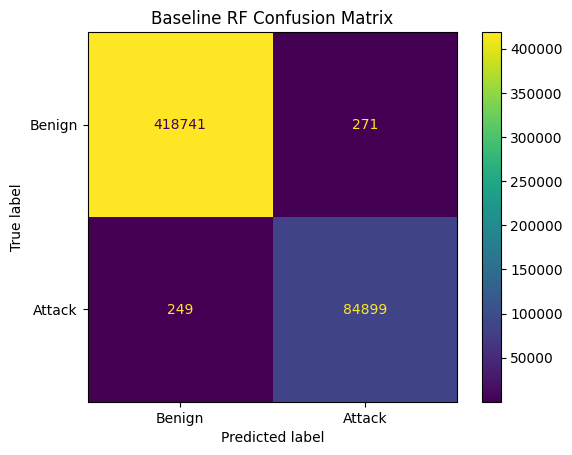

In [7]:
# TODO: Evaluate baseline model
# Metrics needed: accuracy, precision, recall, F1, FPR, runtime
# Hint: sklearn.metrics - accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# FPR = FP / (FP + TN) - you can get FP and TN from the confusion matrix

accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

cm = metrics.confusion_matrix(y_test, y_pred)
fpr = cm[0][1] / (cm[0][1] + cm[0][0])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("False Positive Rate:", fpr)

metrics.ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack']).plot()
plt.title('Baseline RF Confusion Matrix')
plt.show()

## 4. Metaheuristic Optimisation

Each metaheuristic below should optimise:
- **Feature selection** - which subset of features to use
- **Hyperparameter tuning** - RF hyperparams (e.g. n_estimators, max_depth, min_samples_split)

### 4a. Genetic Algorithm (GA)

In [8]:
# TODO: Define fitness function
# Hint: Each individual encodes feature selection (binary) + hyperparams
# Fitness = model performance (e.g. F1 score) on a validation set

def fitness(individual, X_train, y_train, X_test, y_test):
    feature_mask = individual[:70]
    selected = [i for i, bit in enumerate(feature_mask) if bit == 1]
    
    if len(selected) == 0:
        return 0
    
    # Sample 10% of training data for speed
    sample_idx = np.random.choice(len(X_train), size=int(len(X_train) * 0.1), replace=False)
    X_sample = X_train.iloc[sample_idx]
    y_sample = y_train.iloc[sample_idx]
    
    n_estimators = individual[70]
    max_depth = individual[71]
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    rf.fit(X_sample.iloc[:, selected], y_sample)
    y_pred = rf.predict(X_test.iloc[:, selected])
    return metrics.f1_score(y_test, y_pred)

def create_individual(n_features):
    features = [random.randint(0, 1) for _ in range(n_features)]
    n_estimators = random.randint(50, 200)
    max_depth = random.randint(5, 30)
    return features + [n_estimators, max_depth]


In [9]:
# TODO: Implement GA - selection, crossover, mutation
# TODO: Track best fitness per generation for convergence curve
# TODO: Time the entire GA run

def tournament_selection(population, fitnesses, k=3):
    selected = random.sample(range(len(population)), k)
    best = max(selected, key=lambda i: fitnesses[i])
    return population[best]

def crossover(parent_a, parent_b):
    point = random.randint(1, len(parent_a) - 1)
    return parent_a[:point] + parent_b[point:]

def mutate(individual, n_features):
    for i in range(n_features):
        if random.random() < 0.05:
            individual[i] = 1 - individual[i]  # flip bit
    return individual


n_features = X_train.shape[1]                                # number of features (70)
pop_size = 20                                                # 20 individuals in population
generations = 30                                             # run for 30 generations

population = [create_individual(n_features) for _ in range(pop_size)]  # random starting population
best_fitness_history = []                                    # track best fitness each generation
best_individual = None                                       # track the overall best solution
best_score = 0

start_ga = time.time()

for gen in range(generations):
    # Evaluate fitness of every individual
    fitnesses = [fitness(ind, X_train, y_train, X_test, y_test) for ind in population]
    
    # Track the best
    gen_best = max(fitnesses)                                # best fitness this generation
    best_fitness_history.append(gen_best)                    # save for convergence curve
    
    if gen_best > best_score:                                # if new overall best
        best_score = gen_best
        best_individual = population[fitnesses.index(gen_best)]  # save that individual
    
    print(f"Generation {gen}: Best F1 = {gen_best:.4f}")
    
    # Build next generation
    new_population = []
    for _ in range(pop_size):
        parent_a = tournament_selection(population, fitnesses)   # pick parent A
        parent_b = tournament_selection(population, fitnesses)   # pick parent B
        child = crossover(parent_a, parent_b)                    # breed them
        child = mutate(child, n_features)                        # mutate the child
        new_population.append(child)
    population = new_population                              # replace old generation

end_ga = time.time()
print(f"GA completed in {end_ga - start_ga:.2f} seconds")
print(f"Best F1: {best_score:.4f}")
print(f"Features selected: {sum(best_individual[:n_features])}/{n_features}")


Generation 0: Best F1 = 0.9958
Generation 1: Best F1 = 0.9965
Generation 2: Best F1 = 0.9965
Generation 3: Best F1 = 0.9965
Generation 4: Best F1 = 0.9967
Generation 5: Best F1 = 0.9969
Generation 6: Best F1 = 0.9968
Generation 7: Best F1 = 0.9968
Generation 8: Best F1 = 0.9968
Generation 9: Best F1 = 0.9970
Generation 10: Best F1 = 0.9969
Generation 11: Best F1 = 0.9971
Generation 12: Best F1 = 0.9969
Generation 13: Best F1 = 0.9970
Generation 14: Best F1 = 0.9970
Generation 15: Best F1 = 0.9970
Generation 16: Best F1 = 0.9969
Generation 17: Best F1 = 0.9971
Generation 18: Best F1 = 0.9971
Generation 19: Best F1 = 0.9971
Generation 20: Best F1 = 0.9971
Generation 21: Best F1 = 0.9971
Generation 22: Best F1 = 0.9971
Generation 23: Best F1 = 0.9971
Generation 24: Best F1 = 0.9970
Generation 25: Best F1 = 0.9971
Generation 26: Best F1 = 0.9971
Generation 27: Best F1 = 0.9973
Generation 28: Best F1 = 0.9971
Generation 29: Best F1 = 0.9971
GA completed in 10279.83 seconds
Best F1: 0.9973
F

GA Results:
Accuracy: 0.9991649476356712
Precision: 0.9966587336014162
Recall: 0.9984027810400714
F1 Score: 0.9975299950130541
False Positive Rate: 0.000680171450936966
Features selected: 27 / 70
GA Runtime: 10279.828351020813 seconds


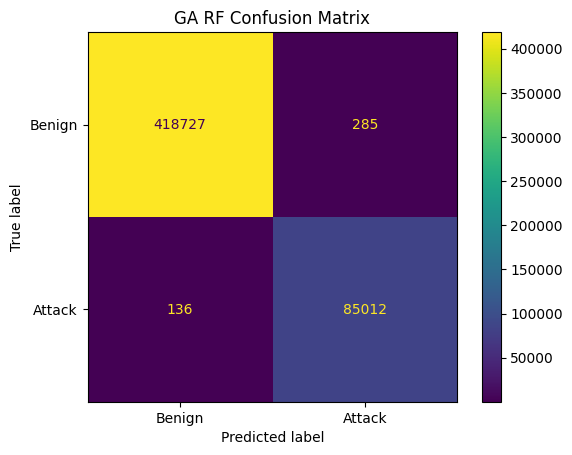

In [22]:
# TODO: Evaluate best GA solution on test set
# Record: accuracy, precision, recall, F1, FPR, num features selected, runtime

selected_ga = [i for i, bit in enumerate(best_individual[:n_features]) if bit == 1]
rf_ga = RandomForestClassifier(n_estimators=best_individual[70], max_depth=best_individual[71], random_state=42)
rf_ga.fit(X_train.iloc[:, selected_ga], y_train)
y_pred_ga = rf_ga.predict(X_test.iloc[:, selected_ga])

accuracy_ga = metrics.accuracy_score(y_test, y_pred_ga)
precision_ga = metrics.precision_score(y_test, y_pred_ga)
recall_ga = metrics.recall_score(y_test, y_pred_ga)
f1_ga = metrics.f1_score(y_test, y_pred_ga)

cm_ga = metrics.confusion_matrix(y_test, y_pred_ga)
fpr_ga = cm_ga[0][1] / (cm_ga[0][1] + cm_ga[0][0])

print("GA Results:")
print("Accuracy:", accuracy_ga)
print("Precision:", precision_ga)
print("Recall:", recall_ga)
print("F1 Score:", f1_ga)
print("False Positive Rate:", fpr_ga)
print("Features selected:", len(selected_ga), "/", n_features)
print("GA Runtime:", end_ga - start_ga, "seconds")

metrics.ConfusionMatrixDisplay(cm_ga, display_labels=['Benign', 'Attack']).plot()
plt.title('GA RF Confusion Matrix')
plt.show()


### 4b. Particle Swarm Optimisation (PSO)

In [23]:
# PSO reuses the same fitness function defined in the GA section
# Each particle's position is a continuous vector of length 72:
#   - Positions 0-69: feature selection (sigmoid threshold > 0.5 = selected)
#   - Position 70: n_estimators (continuous, rounded to int in [50, 200])
#   - Position 71: max_depth (continuous, rounded to int in [5, 30])

def sigmoid(x):
    """Sigmoid function to convert continuous position to selection probability."""
    return 1 / (1 + np.exp(-x))

def decode_particle(position, n_features):
    """Convert continuous PSO position into a discrete individual for fitness evaluation."""
    # Feature bits: apply sigmoid threshold
    feature_bits = [1 if sigmoid(position[i]) > 0.5 else 0 for i in range(n_features)]
    
    # Hyperparams: clamp to valid ranges
    n_estimators = int(np.clip(round(position[n_features]), 50, 200))
    max_depth = int(np.clip(round(position[n_features + 1]), 5, 30))
    
    return feature_bits + [n_estimators, max_depth]

In [24]:
# PSO parameters
n_particles = 20          # swarm size (same as GA pop_size)
n_iterations = 30         # number of iterations (same as GA generations)
dim = n_features + 2      # 70 features + 2 hyperparams

# PSO coefficients
w = 0.7                   # inertia weight
c1 = 1.5                  # cognitive (personal best) coefficient
c2 = 1.5                  # social (global best) coefficient

# Initialise particle positions and velocities
# Feature dims initialised around 0 (sigmoid(0)=0.5, so roughly half selected)
# n_estimators initialised in [50, 200], max_depth in [5, 30]
positions = np.random.uniform(-2, 2, (n_particles, dim))
positions[:, n_features] = np.random.uniform(50, 200, n_particles)      # n_estimators
positions[:, n_features + 1] = np.random.uniform(5, 30, n_particles)    # max_depth

velocities = np.random.uniform(-1, 1, (n_particles, dim))

# Personal and global bests
pbest_positions = positions.copy()
pbest_scores = np.zeros(n_particles)
gbest_position = None
gbest_score = 0

best_fitness_history_pso = []  # track best fitness per iteration

start_pso = time.time()

for iteration in range(n_iterations):
    for i in range(n_particles):
        # Decode particle position into individual and evaluate fitness
        individual = decode_particle(positions[i], n_features)
        score = fitness(individual, X_train, y_train, X_test, y_test)
        
        # Update personal best
        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest_positions[i] = positions[i].copy()
        
        # Update global best
        if score > gbest_score:
            gbest_score = score
            gbest_position = positions[i].copy()
    
    best_fitness_history_pso.append(gbest_score)
    print(f"PSO Iteration {iteration}: Best F1 = {gbest_score:.4f}")
    
    # Update velocities and positions
    for i in range(n_particles):
        r1 = np.random.random(dim)
        r2 = np.random.random(dim)
        
        # Velocity update: inertia + cognitive + social
        velocities[i] = (w * velocities[i] 
                        + c1 * r1 * (pbest_positions[i] - positions[i]) 
                        + c2 * r2 * (gbest_position - positions[i]))
        
        # Clamp velocity to prevent explosion
        velocities[i] = np.clip(velocities[i], -4, 4)
        
        # Position update
        positions[i] = positions[i] + velocities[i]
        
        # Clamp hyperparameter dimensions to valid ranges
        positions[i, n_features] = np.clip(positions[i, n_features], 50, 200)
        positions[i, n_features + 1] = np.clip(positions[i, n_features + 1], 5, 30)

end_pso = time.time()
print(f"\nPSO completed in {end_pso - start_pso:.2f} seconds")
print(f"Best F1: {gbest_score:.4f}")
best_individual_pso = decode_particle(gbest_position, n_features)
print(f"Features selected: {sum(best_individual_pso[:n_features])}/{n_features}")
print(f"n_estimators: {best_individual_pso[n_features]}, max_depth: {best_individual_pso[n_features+1]}")

PSO Iteration 0: Best F1 = 0.9969
PSO Iteration 1: Best F1 = 0.9969
PSO Iteration 2: Best F1 = 0.9969
PSO Iteration 3: Best F1 = 0.9969
PSO Iteration 4: Best F1 = 0.9970
PSO Iteration 5: Best F1 = 0.9970
PSO Iteration 6: Best F1 = 0.9970
PSO Iteration 7: Best F1 = 0.9971
PSO Iteration 8: Best F1 = 0.9971
PSO Iteration 9: Best F1 = 0.9972
PSO Iteration 10: Best F1 = 0.9972
PSO Iteration 11: Best F1 = 0.9972
PSO Iteration 12: Best F1 = 0.9972
PSO Iteration 13: Best F1 = 0.9972
PSO Iteration 14: Best F1 = 0.9972
PSO Iteration 15: Best F1 = 0.9972
PSO Iteration 16: Best F1 = 0.9972
PSO Iteration 17: Best F1 = 0.9972
PSO Iteration 18: Best F1 = 0.9972
PSO Iteration 19: Best F1 = 0.9972
PSO Iteration 20: Best F1 = 0.9972
PSO Iteration 21: Best F1 = 0.9972
PSO Iteration 22: Best F1 = 0.9972
PSO Iteration 23: Best F1 = 0.9972
PSO Iteration 24: Best F1 = 0.9972
PSO Iteration 25: Best F1 = 0.9972
PSO Iteration 26: Best F1 = 0.9972
PSO Iteration 27: Best F1 = 0.9972
PSO Iteration 28: Best F1 = 0.

PSO Results:
Accuracy: 0.9991827991113932
Precision: 0.9967056671903209
Recall: 0.9984615023253629
F1 Score: 0.9975828121516492
False Positive Rate: 0.0006706251849589033
Features selected: 32 / 70
PSO Runtime: 11851.921874046326 seconds


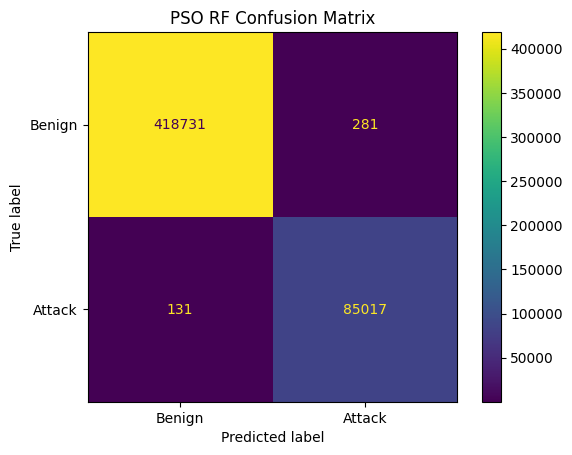

In [25]:
# Evaluate best PSO solution on test set using full training data
selected_pso = [i for i, bit in enumerate(best_individual_pso[:n_features]) if bit == 1]
rf_pso = RandomForestClassifier(
    n_estimators=best_individual_pso[n_features], 
    max_depth=best_individual_pso[n_features + 1], 
    random_state=42
)
rf_pso.fit(X_train.iloc[:, selected_pso], y_train)
y_pred_pso = rf_pso.predict(X_test.iloc[:, selected_pso])

accuracy_pso = metrics.accuracy_score(y_test, y_pred_pso)
precision_pso = metrics.precision_score(y_test, y_pred_pso)
recall_pso = metrics.recall_score(y_test, y_pred_pso)
f1_pso = metrics.f1_score(y_test, y_pred_pso)

cm_pso = metrics.confusion_matrix(y_test, y_pred_pso)
fpr_pso = cm_pso[0][1] / (cm_pso[0][1] + cm_pso[0][0])

print("PSO Results:")
print("Accuracy:", accuracy_pso)
print("Precision:", precision_pso)
print("Recall:", recall_pso)
print("F1 Score:", f1_pso)
print("False Positive Rate:", fpr_pso)
print("Features selected:", len(selected_pso), "/", n_features)
print("PSO Runtime:", end_pso - start_pso, "seconds")

metrics.ConfusionMatrixDisplay(cm_pso, display_labels=['Benign', 'Attack']).plot()
plt.title('PSO RF Confusion Matrix')
plt.show()

### 4c. Simulated Annealing (SA)

In [26]:
# SA reuses the same fitness function defined in the GA section
# Solution encoding is identical: [70 feature bits, n_estimators, max_depth]
# 
# Neighbour generation strategy:
#   - Flip a random number of feature bits (1-3 bits)
#   - Perturb n_estimators by +/- up to 20, clamped to [50, 200]
#   - Perturb max_depth by +/- up to 5, clamped to [5, 30]

def get_neighbour(solution, n_features):
    """Generate a neighbouring solution by small perturbations."""
    neighbour = solution.copy()
    
    # Flip 1-3 random feature bits
    n_flips = random.randint(1, 3)
    for _ in range(n_flips):
        idx = random.randint(0, n_features - 1)
        neighbour[idx] = 1 - neighbour[idx]
    
    # Perturb n_estimators
    neighbour[n_features] = int(np.clip(
        neighbour[n_features] + random.randint(-20, 20), 50, 200
    ))
    
    # Perturb max_depth
    neighbour[n_features + 1] = int(np.clip(
        neighbour[n_features + 1] + random.randint(-5, 5), 5, 30
    ))
    
    return neighbour

In [27]:
# SA parameters
initial_temp = 1.0        # starting temperature
final_temp = 0.01         # stopping temperature
cooling_rate = 0.95       # geometric cooling: T = T * cooling_rate each step
# This gives ~90 temperature steps, with 1 fitness eval per step (~600 total comparable to GA/PSO
# if we do multiple neighbours per temp, but here we keep it simple: 1 neighbour per step)
max_iterations_per_temp = 7  # neighbours evaluated at each temperature (~630 total evals)

# Initialise with a random solution
current_solution = create_individual(n_features)
current_fitness = fitness(current_solution, X_train, y_train, X_test, y_test)

best_solution_sa = current_solution.copy()
best_fitness_sa = current_fitness

best_fitness_history_sa = []  # track best fitness at each temperature step
temp_history = []             # track temperature for plotting

temperature = initial_temp
start_sa = time.time()
step = 0

while temperature > final_temp:
    for _ in range(max_iterations_per_temp):
        # Generate a neighbour
        neighbour = get_neighbour(current_solution, n_features)
        neighbour_fitness = fitness(neighbour, X_train, y_train, X_test, y_test)
        
        # Calculate fitness difference (we are maximising, so higher is better)
        delta = neighbour_fitness - current_fitness
        
        # Accept if better, or with probability exp(delta/T) if worse
        if delta > 0 or random.random() < np.exp(delta / temperature):
            current_solution = neighbour
            current_fitness = neighbour_fitness
        
        # Update best solution found so far
        if current_fitness > best_fitness_sa:
            best_fitness_sa = current_fitness
            best_solution_sa = current_solution.copy()
    
    best_fitness_history_sa.append(best_fitness_sa)
    temp_history.append(temperature)
    print(f"SA Step {step} | Temp: {temperature:.4f} | Current F1: {current_fitness:.4f} | Best F1: {best_fitness_sa:.4f}")
    
    # Cool down
    temperature *= cooling_rate
    step += 1

end_sa = time.time()
print(f"\nSA completed in {end_sa - start_sa:.2f} seconds")
print(f"Best F1: {best_fitness_sa:.4f}")
print(f"Features selected: {sum(best_solution_sa[:n_features])}/{n_features}")
print(f"n_estimators: {best_solution_sa[n_features]}, max_depth: {best_solution_sa[n_features+1]}")
print(f"Total temperature steps: {step}")

SA Step 0 | Temp: 1.0000 | Current F1: 0.9793 | Best F1: 0.9940
SA Step 1 | Temp: 0.9500 | Current F1: 0.9704 | Best F1: 0.9940
SA Step 2 | Temp: 0.9025 | Current F1: 0.9905 | Best F1: 0.9940
SA Step 3 | Temp: 0.8574 | Current F1: 0.9931 | Best F1: 0.9940
SA Step 4 | Temp: 0.8145 | Current F1: 0.9911 | Best F1: 0.9940
SA Step 5 | Temp: 0.7738 | Current F1: 0.9727 | Best F1: 0.9940
SA Step 6 | Temp: 0.7351 | Current F1: 0.9366 | Best F1: 0.9940
SA Step 7 | Temp: 0.6983 | Current F1: 0.9729 | Best F1: 0.9940
SA Step 8 | Temp: 0.6634 | Current F1: 0.9894 | Best F1: 0.9942
SA Step 9 | Temp: 0.6302 | Current F1: 0.9940 | Best F1: 0.9949
SA Step 10 | Temp: 0.5987 | Current F1: 0.9941 | Best F1: 0.9950
SA Step 11 | Temp: 0.5688 | Current F1: 0.9472 | Best F1: 0.9950
SA Step 12 | Temp: 0.5404 | Current F1: 0.9873 | Best F1: 0.9950
SA Step 13 | Temp: 0.5133 | Current F1: 0.9286 | Best F1: 0.9950
SA Step 14 | Temp: 0.4877 | Current F1: 0.9841 | Best F1: 0.9950
SA Step 15 | Temp: 0.4633 | Current

SA Results:
Accuracy: 0.999101475721993
Precision: 0.9969605576613897
Recall: 0.99772161413069
F1 Score: 0.9973409407082607
False Positive Rate: 0.0006181207220795586
Features selected: 31 / 70
SA Runtime: 13176.044299840927 seconds


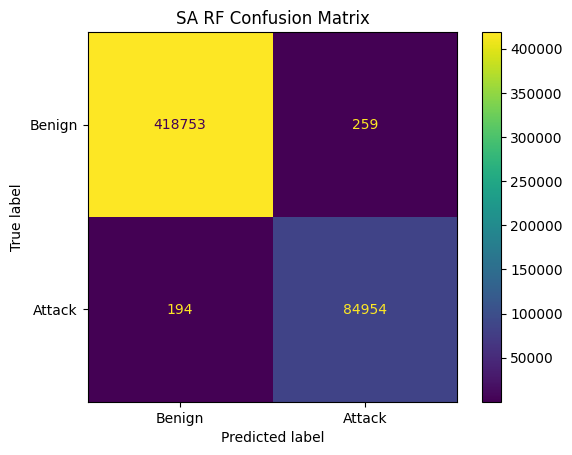

In [28]:
# Evaluate best SA solution on test set using full training data
selected_sa = [i for i, bit in enumerate(best_solution_sa[:n_features]) if bit == 1]
rf_sa = RandomForestClassifier(
    n_estimators=best_solution_sa[n_features], 
    max_depth=best_solution_sa[n_features + 1], 
    random_state=42
)
rf_sa.fit(X_train.iloc[:, selected_sa], y_train)
y_pred_sa = rf_sa.predict(X_test.iloc[:, selected_sa])

accuracy_sa = metrics.accuracy_score(y_test, y_pred_sa)
precision_sa = metrics.precision_score(y_test, y_pred_sa)
recall_sa = metrics.recall_score(y_test, y_pred_sa)
f1_sa = metrics.f1_score(y_test, y_pred_sa)

cm_sa = metrics.confusion_matrix(y_test, y_pred_sa)
fpr_sa = cm_sa[0][1] / (cm_sa[0][1] + cm_sa[0][0])

print("SA Results:")
print("Accuracy:", accuracy_sa)
print("Precision:", precision_sa)
print("Recall:", recall_sa)
print("F1 Score:", f1_sa)
print("False Positive Rate:", fpr_sa)
print("Features selected:", len(selected_sa), "/", n_features)
print("SA Runtime:", end_sa - start_sa, "seconds")

metrics.ConfusionMatrixDisplay(cm_sa, display_labels=['Benign', 'Attack']).plot()
plt.title('SA RF Confusion Matrix')
plt.show()

## 5. Evaluation & Comparison

In [29]:
# TODO: Create comparison table - Baseline vs GA vs PSO vs SA
# Columns: accuracy, precision, recall, F1, FPR, num features, runtime
# Hint: pd.DataFrame with results from each method

In [30]:
# TODO: Bar charts comparing metrics across methods
# Hint: matplotlib/seaborn grouped bar charts

In [31]:
# TODO: Convergence curves - best fitness vs generation/iteration for GA, PSO, SA
# Hint: Plot all three on the same graph for easy comparison

In [32]:
# TODO: Confusion matrices for each method
# Hint: sklearn.metrics.ConfusionMatrixDisplay or seaborn heatmap